# EDA — Fraud Detection

Exploration du dataset `fraudTest.csv` : distribution de la fraude, montants, catégories, heure et distance géographique.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'

## 1. Chargement des données

In [2]:
df = pd.read_csv('../01_Data/fraudTest.csv', index_col=0)
print('Shape :', df.shape)
df.head()

Shape : (555719, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 555719 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  555719 non-null  object 
 1   cc_num                 555719 non-null  int64  
 2   merchant               555719 non-null  object 
 3   category               555719 non-null  object 
 4   amt                    555719 non-null  float64
 5   first                  555719 non-null  object 
 6   last                   555719 non-null  object 
 7   gender                 555719 non-null  object 
 8   street                 555719 non-null  object 
 9   city                   555719 non-null  object 
 10  state                  555719 non-null  object 
 11  zip                    555719 non-null  int64  
 12  lat                    555719 non-null  float64
 13  long                   555719 non-null  float64
 14  city_pop               555719 non-null  i

In [4]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [5]:
print('Valeurs manquantes :', df.isnull().sum().sum())

Valeurs manquantes : 0


## 2. Distribution de la variable cible

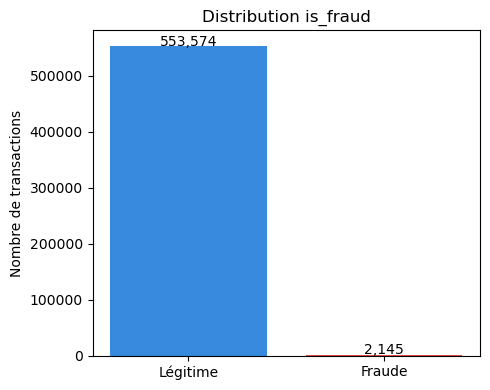

Taux de fraude : 0.39%


In [6]:
counts = df['is_fraud'].value_counts()
taux   = df['is_fraud'].mean() * 100

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Légitime', 'Fraude'], counts.values, color=['#378ADD', '#E24B4A'])
ax.set_title('Distribution is_fraud')
ax.set_ylabel('Nombre de transactions')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Taux de fraude : {taux:.2f}%')

## 3. Distribution des montants

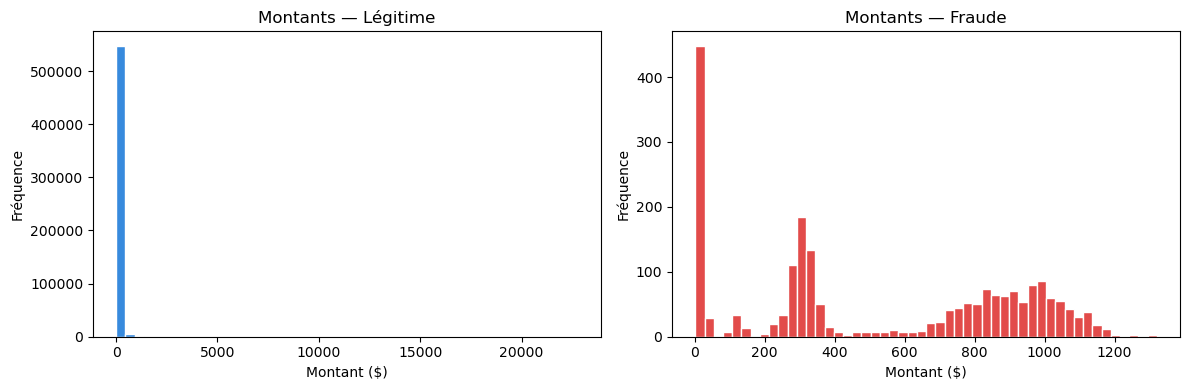

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,553574.0,67.61,152.47,1.00,9.60,47.15,82.62,22768.11
1,2145.0,528.36,392.75,1.78,214.51,371.94,907.77,1320.92


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, label, color in zip(axes, [0, 1], ['#378ADD', '#E24B4A']):
    subset = df[df['is_fraud'] == label]['amt']
    ax.hist(subset, bins=50, color=color, edgecolor='white')
    ax.set_title(f"Montants — {'Fraude' if label else 'Légitime'}")
    ax.set_xlabel('Montant ($)')
    ax.set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

df.groupby('is_fraud')['amt'].describe().round(2)

## 4. Fraudes par catégorie

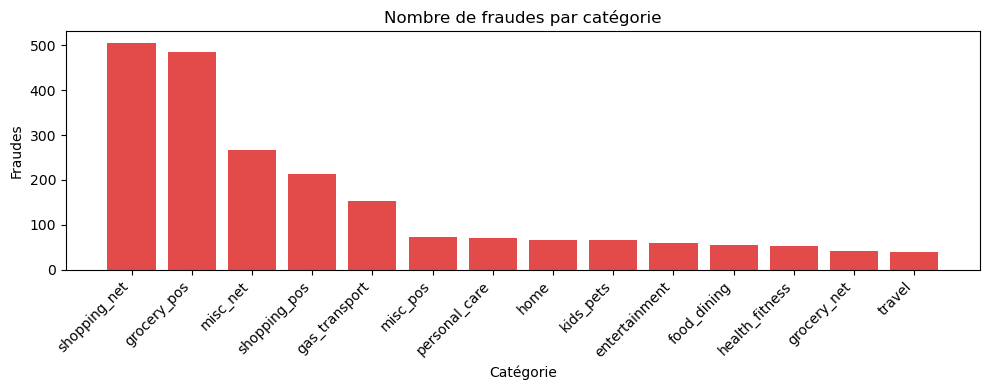

In [8]:
cat_fraud = (
    df[df['is_fraud'] == 1]
    .groupby('category')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='n_fraudes')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cat_fraud['category'], cat_fraud['n_fraudes'], color='#E24B4A')
ax.set_title('Nombre de fraudes par catégorie')
ax.set_xlabel('Catégorie')
ax.set_ylabel('Fraudes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Fraudes par heure

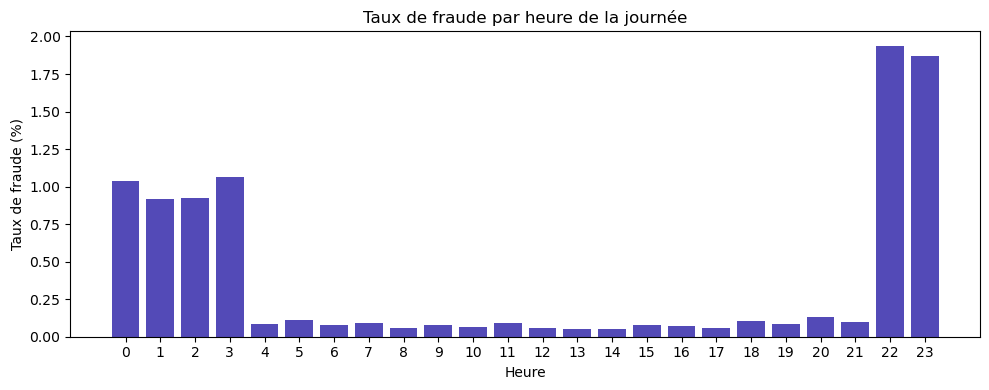

In [9]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour

hourly = df.groupby('hour')['is_fraud'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly.index, hourly.values, color='#534AB7')
ax.set_title('Taux de fraude par heure de la journée')
ax.set_xlabel('Heure')
ax.set_ylabel('Taux de fraude (%)')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

## 6. Distance géographique cardholder / merchant

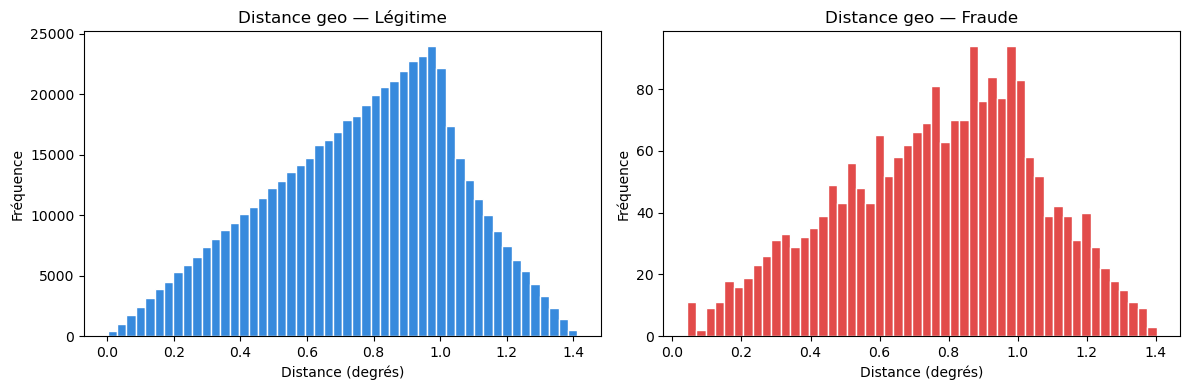

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,553574.0,0.766,0.285,0.001,0.564,0.798,0.977,1.412
1,2145.0,0.768,0.287,0.042,0.563,0.798,0.980,1.402


In [10]:
df['geo_distance'] = np.sqrt(
    (df['lat'] - df['merch_lat']) ** 2 +
    (df['long'] - df['merch_long']) ** 2
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, label, color in zip(axes, [0, 1], ['#378ADD', '#E24B4A']):
    subset = df[df['is_fraud'] == label]['geo_distance']
    ax.hist(subset, bins=50, color=color, edgecolor='white')
    ax.set_title(f"Distance geo — {'Fraude' if label else 'Légitime'}")
    ax.set_xlabel('Distance (degrés)')
    ax.set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

df.groupby('is_fraud')['geo_distance'].describe().round(3)

## 7. Corrélation des features numériques

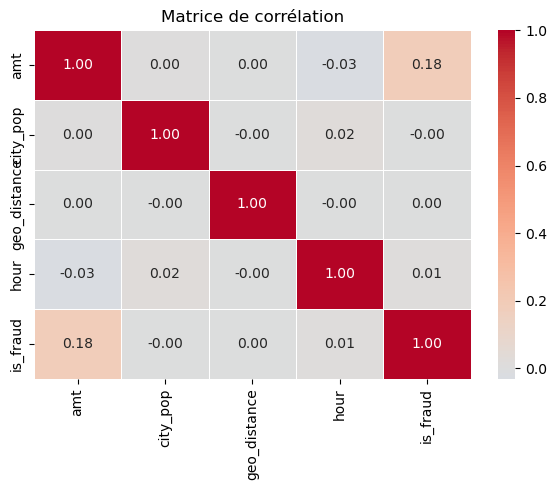

In [11]:
num_cols = ['amt', 'city_pop', 'geo_distance', 'hour', 'is_fraud']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Matrice de corrélation')
plt.tight_layout()
plt.show()